# Data cleaning

**Missing data**:
- Iterative imputer (+/- indicator)
- KNN imputer (+/- indicator)

**Feature encoding**
- One-hot
- Target

## 1. Notebook setup

### 1.1. Imports

In [1]:
# Standard library
import json

# Third party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# Internal imports
from configuration.data_preprocessing import conditions
from helper_functions.data_preprocessing import knn_imputer, iterative_imputer, one_hot_encoder, target_encoder, encode_label

### 1.2. Run configuration

In [2]:
SAMPLE       = 0.10          # Fraction of data to use for training
CV_FOLDS     = 5             # Number of cross-validation folds
SAMPLE_SIZES = [6000, 60000] # Produce final datasets of these sizes (in addition to full dataset)

# Run control flags
RUN_FULL_CONDITION_SWEEP            = False
RUN_ENCODING_SMOOTHING_OPTIMIZATION = False
RUN_IMPUTER_OPTIMIZATION            = False

# Files paths for data
FULL_CONDITION_SWEEP_DATA           = '../data/results/encoding-imputation.csv'
ENCODING_SMOOTHING_DATA             = '../data/results/target-encoding-smoothing.csv'
ITERATIVE_IMPUTER_OPTIMIZATION_DATA = '../data/results/iterative-imputer-optimization.csv'
FINAL_DATASET_BASENAME              = '../data/tmp/preprocessed_data'

## 2. Data preparation

### 2.1. Data loading 

In [3]:
# Load raw data
train_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-train.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

### 2.2. Metadata loading

In [4]:
# Load dataset metadata
with open("../data/schema.json", "r") as f:
    metadata = json.load(f)

# Extract feature lists
features = metadata['features']
categorical_features = metadata['categorical_features']
continuous_features = metadata['continuous_features']
high_cardinality_feature = metadata['high_cardinality_feature']
label = metadata['label']

# Treat 'step_count' like a continuous feature
continuous_features += [high_cardinality_feature]

print(f'Categorical features: {", ".join(categorical_features)}')
print(f'Continuous features: {", ".join(continuous_features)}')
print(f'Label: {label}')

Categorical features: diet_type, stress_level, sleep_quality, physical_activity_level, smoking_alcohol, gender
Continuous features: sleep_duration, heart_rate, bmi, calorie_expenditure, step_count, exercise_duration, water_intake, step_count
Label: health_condition


### 2.3. Data sampling

In [5]:
# Take sample
n = int(len(train_df) * SAMPLE)
train_df = train_df.sample(n=n)

### 2.4. Data cleaning and formatting

In [6]:
# Preserve label column
training_label = train_df['health_condition']

# Remove id and label columns
train_df.drop(['id', 'health_condition'], axis=1, inplace=True)
train_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 69008 entries, 543566 to 480231
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sleep_duration           61411 non-null  float64
 1   heart_rate               68257 non-null  float64
 2   bmi                      67628 non-null  float64
 3   calorie_expenditure      63837 non-null  float64
 4   step_count               67617 non-null  float64
 5   exercise_duration        68308 non-null  float64
 6   water_intake             64676 non-null  float64
 7   diet_type                68319 non-null  object 
 8   stress_level             60583 non-null  object 
 9   sleep_quality            63099 non-null  object 
 10  physical_activity_level  65413 non-null  object 
 11  smoking_alcohol          66147 non-null  object 
 12  gender                   66868 non-null  object 
dtypes: float64(7), object(6)
memory usage: 7.4+ MB


## 3. Experiments

### 3.1. Imputation x encoding strategy

#### 3.1.1. Condition definitions

In [7]:
print(f'Total {len(conditions.keys())} conditions')

Total 32 conditions


#### 3.1.2. Condition testing

In [8]:
%%time

if RUN_FULL_CONDITION_SWEEP:

    results = {
        'Condition': [],
        'Cross-validation score': []
    }

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    for condition_name, condition_params in conditions.items():
        print(f'Evaluating condition: {condition_name}... ', end='')

        cv_scores = []

        # Fold-level preprocessing prevents train/validation leakage
        for train_idx, validation_idx in cv.split(train_df, training_label):
            x_train = train_df.iloc[train_idx].copy()
            x_validation = train_df.iloc[validation_idx].copy()

            y_train = training_label.iloc[train_idx]
            y_validation = training_label.iloc[validation_idx]

            # Apply the feature encoding on fold training data and transform validation data
            if condition_params['Encoder'] == 'One-hot encoder':
                x_train, x_validation = one_hot_encoder(
                    features=categorical_features,
                    train_df=x_train,
                    test_df=x_validation
                )

            elif condition_params['Encoder'] == 'Target encoder':
                x_train, x_validation = target_encoder(
                    features=categorical_features,
                    train_df=x_train,
                    train_label=y_train,
                    test_df=x_validation,
                    smooth=condition_params['Target smoothing']
                )

            # Apply imputation on fold training data and transform validation data
            if condition_params['Imputer'] == 'KNN imputer':
                x_train, x_validation = knn_imputer(
                    features=continuous_features,
                    train_df=x_train,
                    test_df=x_validation,
                    n_neighbors=condition_params['KNN neighbors'],
                    indicator=condition_params['Missing indicator']
                )

            elif condition_params['Imputer'] == 'Iterative imputer':
                x_train, x_validation = iterative_imputer(
                    features=continuous_features,
                    train_df=x_train,
                    test_df=x_validation,
                    indicator=condition_params['Missing indicator']
                )

            model = GradientBoostingClassifier()
            model.fit(x_train, y_train)

            y_pred = model.predict(x_validation)
            score = balanced_accuracy_score(y_validation, y_pred)
            cv_scores.append(score)

        # Collect results
        results['Condition'].extend([condition_name] * CV_FOLDS)
        results['Cross-validation score'].extend(cv_scores)

        print(f'Balanced accuracy: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

    results = pd.DataFrame(results)
    results.sort_values(by='Cross-validation score', ascending=False, inplace=True)
    results.reset_index(drop=True, inplace=True)
    results.to_csv(FULL_CONDITION_SWEEP_DATA, index=False)

else:
    results = pd.read_csv(FULL_CONDITION_SWEEP_DATA)

median_scores = results.groupby('Condition')['Cross-validation score'].median().sort_values(ascending=False)
best_condition = median_scores.index[0]
best_score = median_scores.iloc[0]

print(f'Best condition: {best_condition}')
print(f'Median balanced accuracy: {best_score:.4f}')

print()

Best condition: Target encoding (smoothing 0.1), iterative imputation, +indicator
Median balanced accuracy: 0.8659

CPU times: user 5.31 ms, sys: 19 μs, total: 5.33 ms
Wall time: 4.84 ms


In [9]:
median_scores

Condition
Target encoding (smoothing 0.1), iterative imputation, +indicator             0.865924
Target encoding (smoothing 10.0), iterative imputation, +indicator            0.865924
Target encoding (smoothing 1.0), iterative imputation, +indicator             0.865924
One-hot encoding, iterative imputation, +indicator                            0.862904
One-hot encoding, KNN imputation (3 neighbors), +indicator                    0.860591
Target encoding (smoothing 1.0), iterative imputation, -indicator             0.860231
Target encoding (smoothing 0.1), iterative imputation, -indicator             0.860211
One-hot encoding, KNN imputation (5 neighbors), +indicator                    0.859977
Target encoding (smoothing 10.0), iterative imputation, -indicator            0.859813
One-hot encoding, KNN imputation (3 neighbors), -indicator                    0.859206
One-hot encoding, KNN imputation (7 neighbors), +indicator                    0.858486
One-hot encoding, KNN imputation 

#### 3.1.1. Results

##### 3.1.3.2. Mean score distribution over conditions

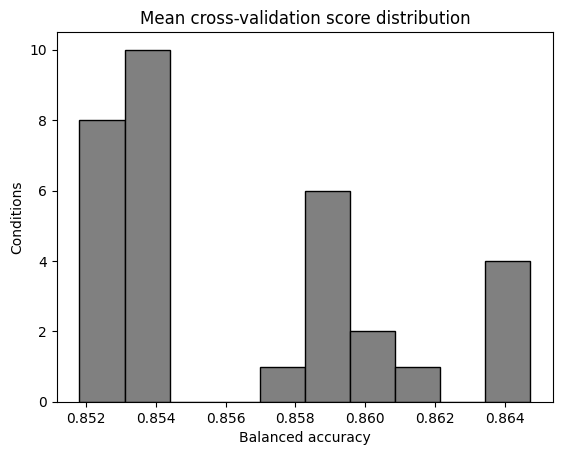

,Cross-validation score
count,32.000000
mean,0.856405
std,0.004320
min,0.851814
25%,0.853245
50%,0.853607
75%,0.858922
max,0.864733


In [10]:
mean_results = pd.DataFrame(results.groupby('Condition').mean())
mean_results.reset_index(drop=False, inplace=True)
mean_results.head()

plt.title('Mean cross-validation score distribution')
plt.hist(mean_results['Cross-validation score'], color='gray', edgecolor='black', bins=10)
plt.xlabel('Balanced accuracy')
plt.ylabel('Conditions')
plt.show()

mean_results.describe()

##### 3.1.3.2. Mean score by condition

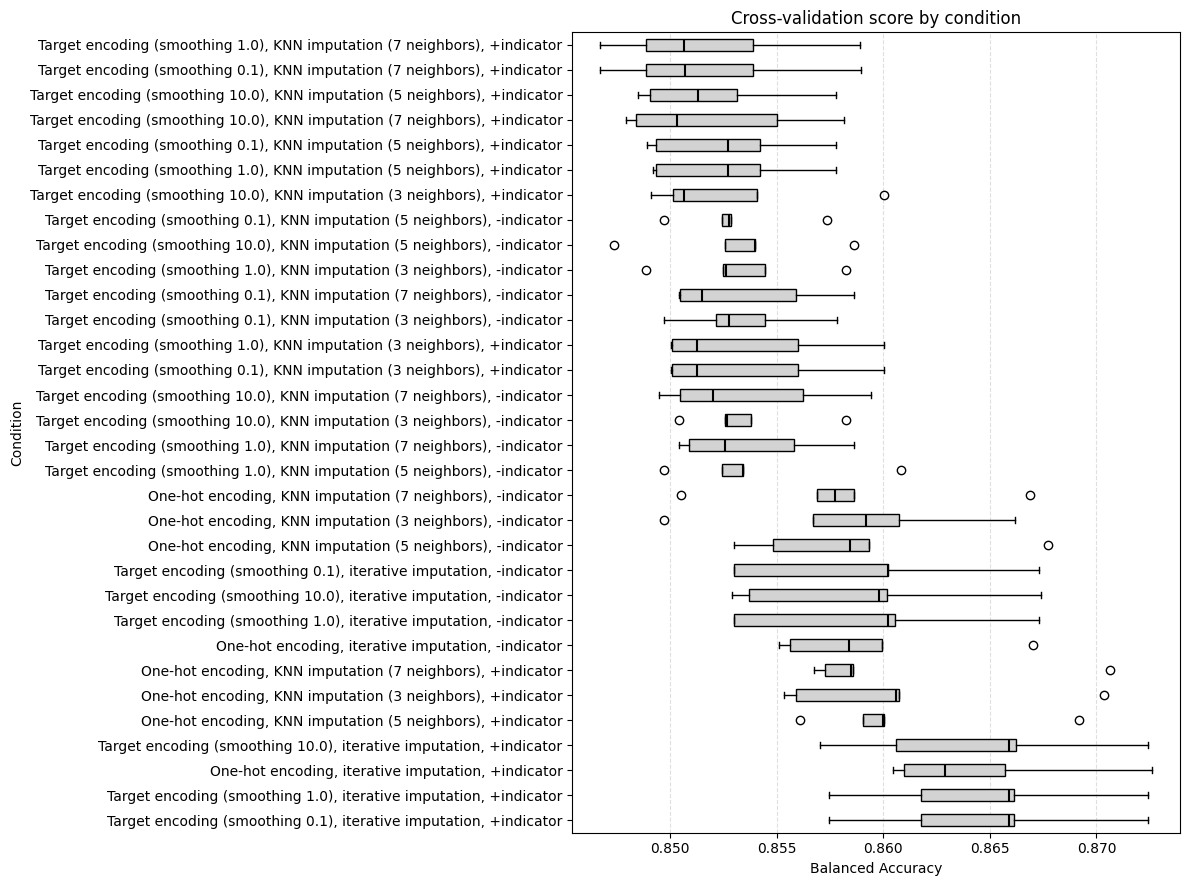

In [11]:
# Order conditions by mean score for a readable top-to-bottom plot
condition_order = (
    results.groupby('Condition')['Cross-validation score']
    .mean()
    .sort_values(ascending=False)
    .index
)

plot_data = [
    results.loc[results['Condition'] == condition, 'Cross-validation score'].values
    for condition in condition_order
]

fig_height = max(6, len(condition_order) * 0.28)
plt.figure(figsize=(12, fig_height))
plt.boxplot(
    plot_data,
    vert=False,
    tick_labels=condition_order,
    patch_artist=True,
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

plt.title('Cross-validation score by condition')
plt.xlabel('Balanced Accuracy')
plt.ylabel('Condition')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Winner is target encoding with iterative imputation and a 'missingness' indicator. Median cross-validation balanced accuracy score is ~0.5 percentage point better than one-hot encoding or KNN imputation.

### 3.2. Target encoding smoothing optimization

**Fixed choices**:
- Imputer: Iterative imputer
- Missing indicator: True

**Sweep**:
- TargetEncoder smooth in [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 'auto']

#### 3.2.1. Optimization run

In [12]:
%%time

if RUN_ENCODING_SMOOTHING_OPTIMIZATION:

    smoothing_values = [1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 'auto']

    target_encoding_results = {
        'Smoothing': [],
        'Cross-validation score': []
    }

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    for smooth_value in smoothing_values:
        print(f'Evaluating smoothing: {smooth_value}... ', end='')

        cv_scores = []

        for train_idx, validation_idx in cv.split(train_df, training_label):
            x_train = train_df.iloc[train_idx].copy()
            x_validation = train_df.iloc[validation_idx].copy()

            y_train = training_label.iloc[train_idx]
            y_validation = training_label.iloc[validation_idx]

            x_train, x_validation = target_encoder(
                features=categorical_features,
                train_df=x_train,
                train_label=y_train,
                test_df=x_validation,
                smooth=smooth_value
            )

            x_train, x_validation = iterative_imputer(
                features=continuous_features,
                train_df=x_train,
                test_df=x_validation,
                indicator=True
            )

            model = GradientBoostingClassifier()
            model.fit(x_train, y_train)

            y_pred = model.predict(x_validation)
            score = balanced_accuracy_score(y_validation, y_pred)
            cv_scores.append(score)

        target_encoding_results['Smoothing'].extend([smooth_value] * CV_FOLDS)
        target_encoding_results['Cross-validation score'].extend(cv_scores)

        print(f'Balanced accuracy: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

    target_encoding_results = pd.DataFrame(target_encoding_results)
    target_encoding_results.sort_values(by='Cross-validation score', ascending=False, inplace=True)
    target_encoding_results.reset_index(drop=True, inplace=True)
    target_encoding_results.to_csv(ENCODING_SMOOTHING_DATA, index=False)

else:
    target_encoding_results = pd.read_csv(ENCODING_SMOOTHING_DATA)
    median_smoothing_scores = target_encoding_results.groupby('Smoothing')['Cross-validation score'].median().sort_values(ascending=False)
    best_target_smoothing = median_smoothing_scores.index[0]
    best_target_smoothing_score = median_smoothing_scores.iloc[0]

print(f'Best target smoothing: {best_target_smoothing}')
print(f'Median balanced accuracy: {best_target_smoothing_score:.4f}')
print()

Best target smoothing: 1.0
Median balanced accuracy: 0.8639

CPU times: user 4.24 ms, sys: 23 μs, total: 4.27 ms
Wall time: 3.63 ms


#### 3.2.2. Results

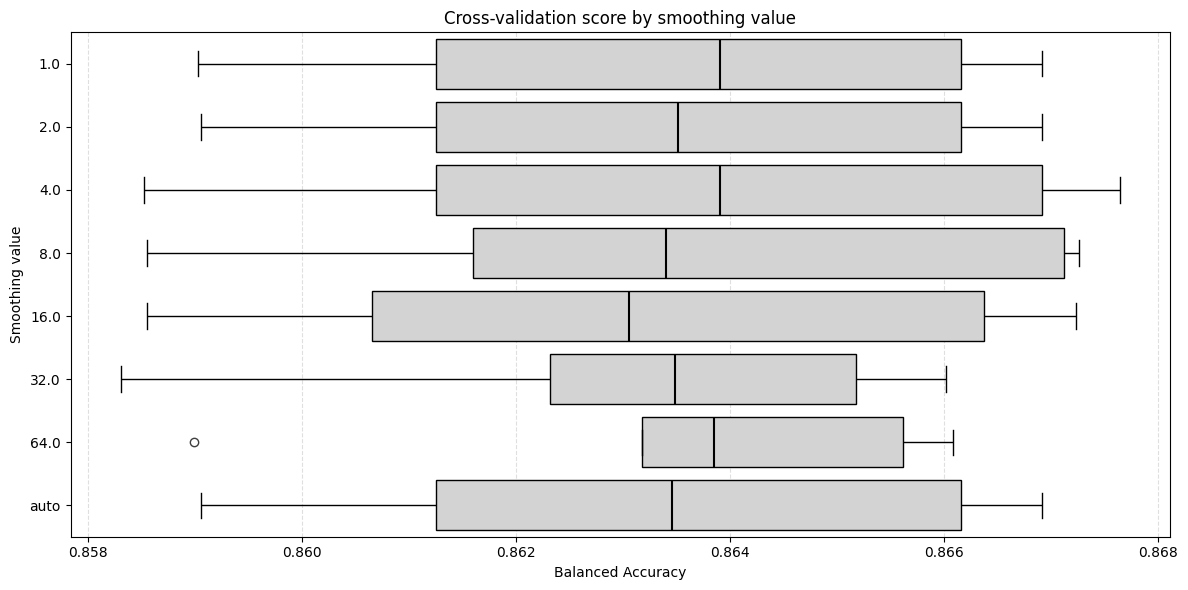

In [13]:
# Force display order: numeric smoothing values ascending, then 'auto' last
numeric_smoothing = sorted(
    float(value)
    for value in target_encoding_results['Smoothing'].unique()
    if str(value).lower() != 'auto'
)

has_auto = any(str(value).lower() == 'auto' for value in target_encoding_results['Smoothing'])

smoothing_order = [str(value) for value in numeric_smoothing]

if has_auto:
    smoothing_order.append('auto')

plot_df = target_encoding_results.copy()
plot_df['Smoothing'] = plot_df['Smoothing'].astype(str)

fig_height = max(6, len(smoothing_order) * 0.5)

plt.figure(figsize=(12, fig_height))
sns.boxplot(
    x='Cross-validation score',
    y='Smoothing',
    data=plot_df,
    order=smoothing_order,
    orient='h',
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

plt.title('Cross-validation score by smoothing value')
plt.xlabel('Balanced Accuracy')
plt.ylabel('Smoothing value')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.3. Iterative imputer optimization

**Fixed choices**:
- Encoder: Target encoder
- Missing indicator: True
- Target smoothing: best value from section 1.0

**Sweep**:
- max_iter in [5, 10, 20]
- initial_strategy in ['mean', 'median']
- imputation_order in ['ascending', 'roman', 'random']

#### 3.3.1. Optimization run

In [14]:
%%time

if RUN_IMPUTER_OPTIMIZATION:

    iterative_conditions = []

    for max_iter in [5, 10, 20]:
        for initial_strategy in ['mean', 'median']:
            for imputation_order in ['ascending', 'roman', 'random']:
                iterative_conditions.append({
                    'max_iter': max_iter,
                    'initial_strategy': initial_strategy,
                    'imputation_order': imputation_order
                })

    iterative_results = {
        'Condition': [],
        'Cross-validation score': []
    }

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=315)

    for condition in iterative_conditions:
        condition_name = (
            f"Target encoding (smoothing {best_target_smoothing}), "
            f"iterative imputation (max_iter={condition['max_iter']}, "
            f"initial={condition['initial_strategy']}, "
            f"order={condition['imputation_order']}), +indicator"
        )

        print(f'Evaluating condition: {condition_name}... ', end='')
        cv_scores = []

        for train_idx, validation_idx in cv.split(train_df, training_label):
            x_train = train_df.iloc[train_idx].copy()
            x_validation = train_df.iloc[validation_idx].copy()

            y_train = training_label.iloc[train_idx]
            y_validation = training_label.iloc[validation_idx]

            x_train, x_validation = target_encoder(
                features=categorical_features,
                train_df=x_train,
                train_label=y_train,
                test_df=x_validation,
                smooth=best_target_smoothing
            )

            x_train, x_validation = iterative_imputer(
                features=continuous_features,
                train_df=x_train,
                test_df=x_validation,
                indicator=True,
                max_iter=condition['max_iter'],
                initial_strategy=condition['initial_strategy'],
                imputation_order=condition['imputation_order'],
                random_state=315
            )

            model = GradientBoostingClassifier()
            model.fit(x_train, y_train)

            y_pred = model.predict(x_validation)
            score = balanced_accuracy_score(y_validation, y_pred)
            cv_scores.append(score)

        iterative_results['Condition'].extend([condition_name] * CV_FOLDS)
        iterative_results['Cross-validation score'].extend(cv_scores)

        print(f'Balanced accuracy: {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}')

    iterative_results = pd.DataFrame(iterative_results)
    iterative_results.sort_values(by='Cross-validation score', ascending=False, inplace=True)
    iterative_results.reset_index(drop=True, inplace=True)
    iterative_results.to_csv(ITERATIVE_IMPUTER_OPTIMIZATION_DATA, index=False)

else:
    iterative_results = pd.read_csv(ITERATIVE_IMPUTER_OPTIMIZATION_DATA)
    print('Loaded iterative imputer optimization results from disk')

median_iterative_scores = iterative_results.groupby('Condition')['Cross-validation score'].median().sort_values(ascending=False)
best_condition = median_iterative_scores.index[0]
best_score = median_iterative_scores.iloc[0]

print(f'Best condition: {best_condition}')
print(f'Median balanced accuracy: {best_score:.4f}')
print()

Loaded iterative imputer optimization results from disk
Best condition: Target encoding (smoothing 1.0), iterative imputation (max_iter=10, initial=mean, order=ascending), +indicator
Median balanced accuracy: 0.8639

CPU times: user 3.16 ms, sys: 909 μs, total: 4.07 ms
Wall time: 3.62 ms


#### 3.3.2. Results

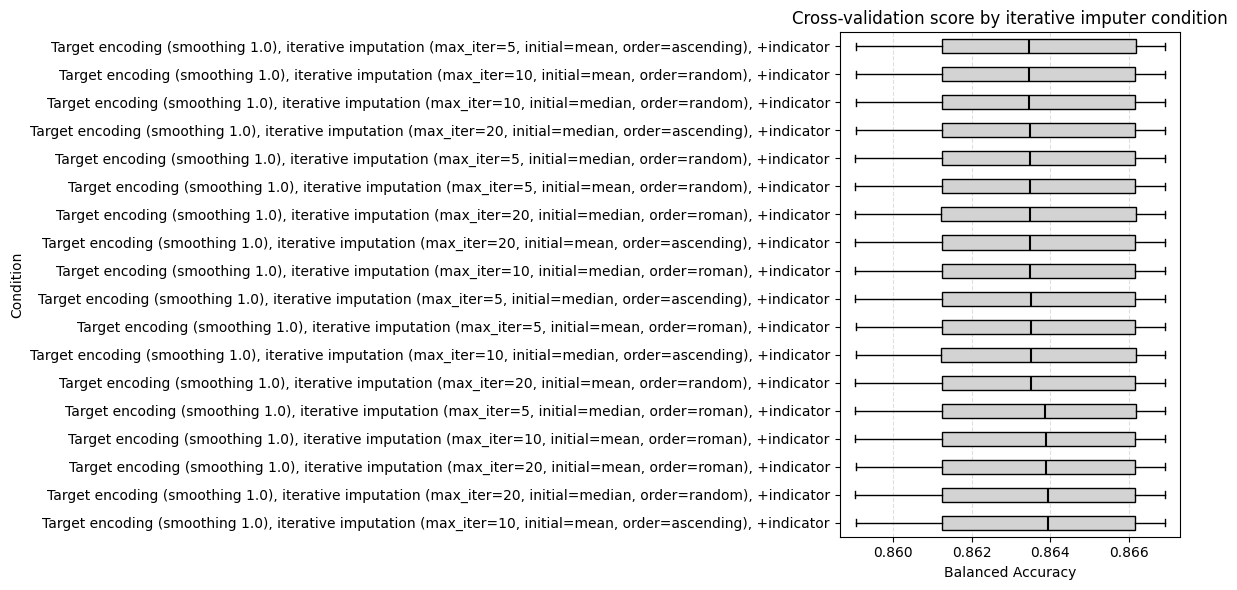

In [15]:
# Order conditions by mean score for a readable top-to-bottom plot
condition_order = (
    iterative_results.groupby('Condition')['Cross-validation score']
    .median()
    .sort_values(ascending=False)
    .index
)

plot_data = [
    iterative_results.loc[iterative_results['Condition'] == condition, 'Cross-validation score'].values
    for condition in condition_order
]

fig_height = max(6, len(condition_order) * 0.28)

plt.figure(figsize=(12, fig_height))
plt.boxplot(
    plot_data,
    vert=False,
    tick_labels=condition_order,
    patch_artist=True,
    boxprops={'facecolor': 'lightgray', 'edgecolor': 'black'},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black'},
    capprops={'color': 'black'}
)

plt.title('Cross-validation score by iterative imputer condition')
plt.xlabel('Balanced Accuracy')
plt.ylabel('Condition')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Conclusion

The final optimized data preprocessing pipeline is:

1. Iterative imputation
    - `max_iter`: 10
    - `initial`: mean
    - `order`: ascending

2. Target encoding
    - `smoothing`: 1.0

A missing indicator is included for all features. For categorical data, the encoder handles `NaN` as and additional category. For each imputed continuous features, a binary indicator feature is added.

## 5. Final dataset

In [16]:
%%time

# Load clean copy of raw training data
train_df = pd.read_csv('https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/student-health-risk-train.csv')

for sample_size in SAMPLE_SIZES + [len(train_df)]:

    sample_df = train_df.sample(n=sample_size)

    # Preserve label column
    training_label = sample_df['health_condition']

    # Remove id and label columns
    sample_df.drop(['id', 'health_condition'], axis=1, inplace=True)

    # Target encoding with smoothing 1.0
    sample_df = target_encoder(
        features=categorical_features,
        train_df=sample_df,
        train_label=training_label,
        smooth=1.0
    )

    # Iterative imputation with max_iter=20, initial_strategy='mean',
    # imputation_order='ascending', and indicator=True
    x_train = iterative_imputer(
        features=continuous_features,
        train_df=sample_df,
        indicator=True,
        max_iter=20,
        initial_strategy='mean',
        imputation_order='ascending'
    )

    # Add the labels back to the preprocessed data
    sample_df = pd.concat([
        sample_df.reset_index(drop=True),
        training_label.reset_index(drop=True)
    ], axis=1)

    # Save with sample size in filename
    sample_df.to_csv(f'{FINAL_DATASET_BASENAME}-n{sample_size}.csv', index=False)

CPU times: user 40min 7s, sys: 23 s, total: 40min 30s
Wall time: 4min 41s
